# 2026 07 16 Python 실습코드

In [1]:
# 기본 셋업 (맨 처음 한 번 실행)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib                 # 그래프 한글 폰트 자동 적용
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

print("준비 완료 - numpy", np.__version__, "/ pandas", pd.__version__, "/ seaborn", sns.__version__)


준비 완료 - numpy 2.5.1 / pandas 3.0.3 / seaborn 0.13.2


In [2]:
# Mile per Gallon에 대한 정보
df = sns.load_dataset("mpg")
print(df.info())
df

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB
None


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [3]:
# DataFrame의 통계정보
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


<Axes: xlabel='weight', ylabel='acceleration'>

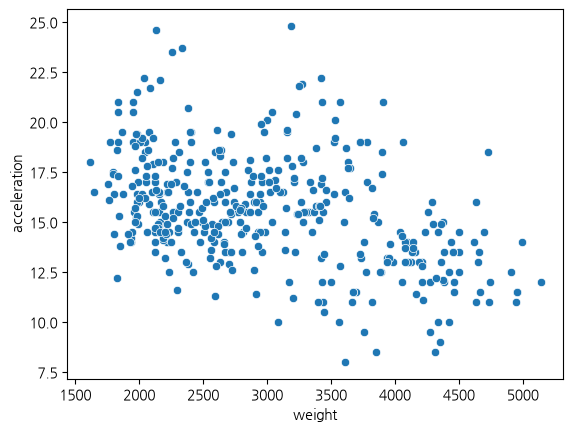

In [4]:
sns.scatterplot(data = df, x = "weight", y = 'acceleration')

<Axes: xlabel='weight', ylabel='acceleration'>

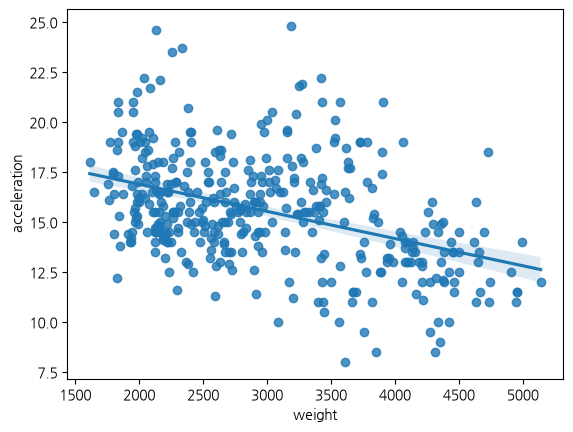

In [5]:
sns.regplot(data = df, x = 'weight', y = 'acceleration')

<Axes: >

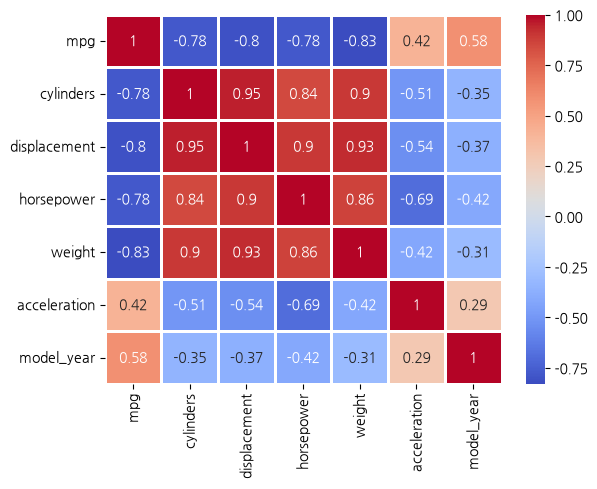

In [6]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm', linewidths=1)

<Axes: xlabel='weight', ylabel='Count'>

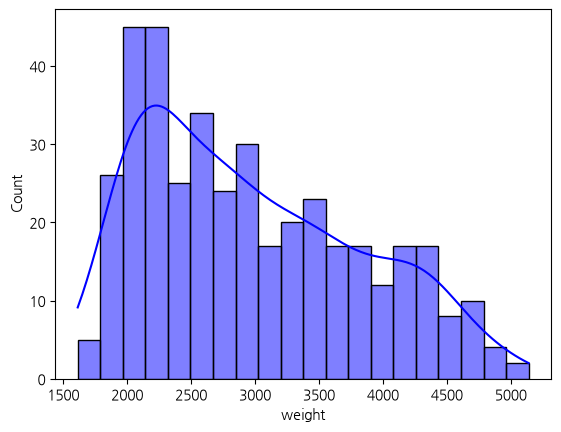

In [7]:
sns.histplot(df["weight"], bins = 20, kde = True, color = 'blue')

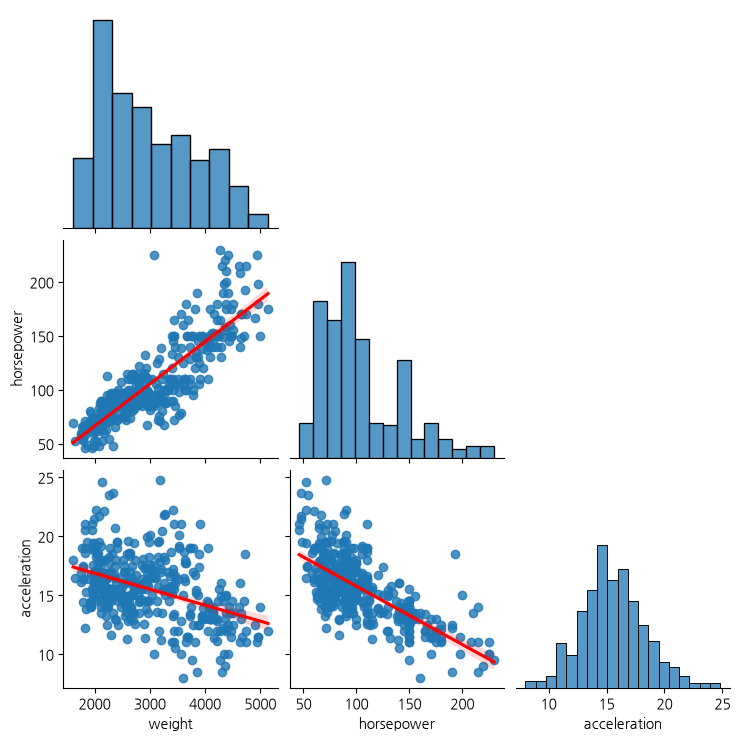

In [8]:
df = df.dropna(subset = ['horsepower'])
sns.pairplot(df[['weight', 'horsepower', 'acceleration']], corner = True, kind = 'reg', plot_kws = {'line_kws' : {'color' : 'red'}})

## 머신러닝 - 선형 회귀

In [9]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

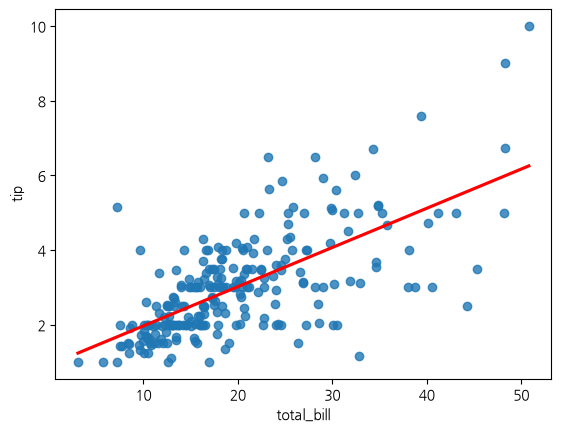

In [10]:
sns.regplot(data = tips, x = 'total_bill', y = 'tip', ci = None, line_kws =  {'color' : 'red'})

In [11]:
X = tips['total_bill'].values
y = tips['tip'].values

# 반복문을 이용해서 선형 회귀 구하기
a_values = np.linspace(0,2,100)
b_values = np.linspace(0,5,100)

best_a, best_b = None, None
min_error = float("inf")

for a in a_values:
  for b in b_values:
    y_hat = a*X + b
    error = np.sum(np.abs(y - y_hat))

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print(best_a, best_b, min_error)

0.12121212121212122 0.5555555555555556 179.96868686868686


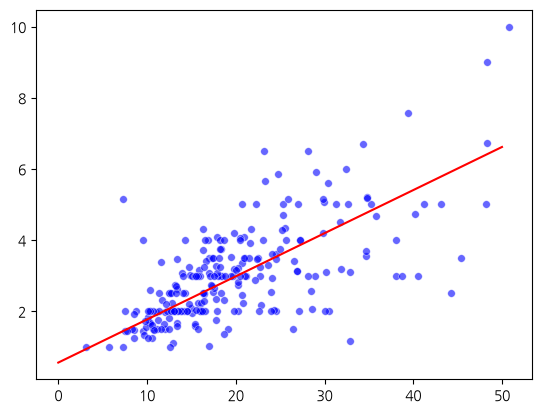

In [12]:
sns.scatterplot(x = X, y = y, s = 30, color = 'blue', alpha = 0.6)

x_line = np.linspace(0,50,100)
y_line = best_a * x_line + best_b
plt.plot(x_line, y_line, color = 'red')
plt.show()

In [13]:
X = tips['total_bill'].values
y = tips['tip'].values

# 반복문을 이용해서 선형 회귀 구하기
a_values = np.linspace(0,2,100)
b_values = np.linspace(0,5,100)

best_a, best_b = None, None
min_error = float("inf")

# MAE
for a in a_values:
  for b in b_values:
    y_hat = a*X + b
    # error = np.sum(np.abs(y - y_hat))
    error = np.mean(np.abs(y - y_hat))

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print(best_a, best_b, min_error)

0.12121212121212122 0.5555555555555556 0.7375765855274051


In [14]:
# MSE
from sklearn.metrics import mean_squared_error

X = tips['total_bill'].values
y = tips['tip'].values

# 반복문을 이용해서 선형 회귀 구하기
a_values = np.linspace(0,2,100)
b_values = np.linspace(0,5,100)

best_a, best_b = None, None
min_error = float("inf")

# MAE
for a in a_values:
  for b in b_values:
    y_hat = a*X + b
    # error = np.sum(np.abs(y - y_hat))
    error = np.mean(np.abs(y - y_hat) ** 2)

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print(best_a, best_b, min_error)

0.10101010101010102 1.0101010101010102 1.0373996209821346


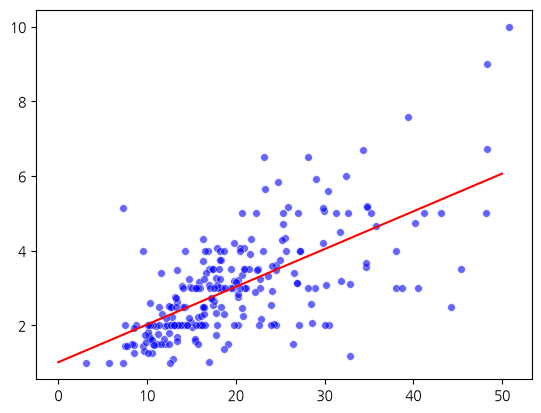

In [15]:
sns.scatterplot(x = X, y = y, s = 30, color = 'blue', alpha = 0.6)

x_line = np.linspace(0,50,100)
y_line = best_a * x_line + best_b
plt.plot(x_line, y_line, color = 'red')
plt.show()

# Gradient Descent

a : 0.10311447575749164, b : -0.3749789803337916
Epoch : 0, MSE = 2.8133, a = 0.1296, b = -0.3736
Epoch : 100, MSE = 1.3072, a = 0.1585, b = -0.3509
Epoch : 200, MSE = 1.2983, a = 0.1576, b = -0.3298
Epoch : 300, MSE = 1.2897, a = 0.1567, b = -0.3090
Epoch : 400, MSE = 1.2813, a = 0.1559, b = -0.2886
Epoch : 500, MSE = 1.2732, a = 0.1550, b = -0.2685
Epoch : 600, MSE = 1.2654, a = 0.1542, b = -0.2488
Epoch : 700, MSE = 1.2579, a = 0.1534, b = -0.2294
Epoch : 800, MSE = 1.2505, a = 0.1526, b = -0.2103
Epoch : 900, MSE = 1.2435, a = 0.1518, b = -0.1915


<function matplotlib.pyplot.show(close=None, block=None)>

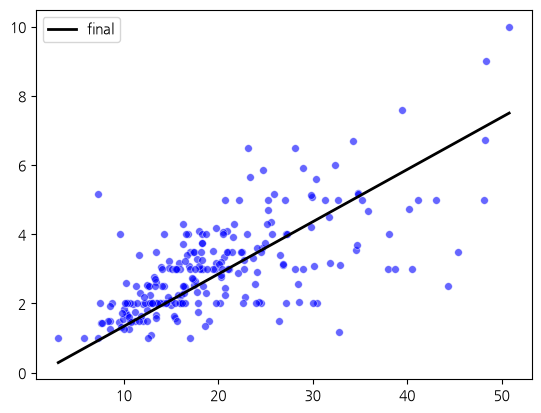

In [16]:
X = tips['total_bill'].values
y = tips['tip'].values

# 파라미터 초기화
a = np.random.randn()
b = np.random.randn()
print(f"a : {a}, b : {b}")

# 하이퍼 파라미터
lr = 0.001
epochs = 1000

for epoch in range(epochs):
  y_hat = a * X + b
  error = y_hat - y
  grad_a = np.mean(error * X)
  grad_b = np.mean(error)

  a -= grad_a * lr
  b -= grad_b * lr

  if epoch % 100 == 0:
    mse = np.mean(np.abs(y - y_hat) ** 2)
    print(f"Epoch : {epoch}, MSE = {mse:.4f}, a = {a:.4f}, b = {b:.4f}")

x_line = np.linspace(X.min(), X.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color='black', linewidth=2, label="final")
sns.scatterplot(x = X, y = y, s = 30, color = 'blue', alpha = 0.6)
plt.show


# 로지스틱 회귀

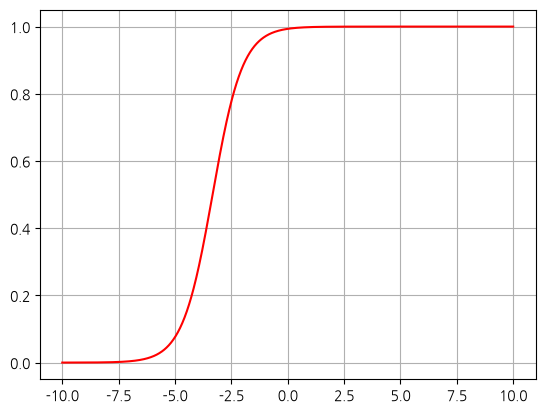

In [17]:
def sigmoid(z):
  return 1/ (1 + np.exp(-z))

a = 1.5
b = 5

X = np.linspace(-10,10,1000)
y_hat = sigmoid(a * X + b)

plt.plot(X, y_hat, color = 'red')
plt.grid(True)
plt.show()

In [18]:
# 공부시간
X = np.array([1,5,2,6,7,3,1,2,3,4])
# 합격 여부 0 : 불합격 / 1: 합격
y = np.array([0,1,0,1,1,0,0,0,0,1])

def get_loss(y, y_hat):
  # return np.sum((y - y_hat) ** 2)
  eps = 1e-10
  return -np.mean(y * np.log(y_hat+ eps) + (1-y) * np.log(1 - y_hat + eps))

# 반복문을 이용해서 선형 회귀 구하기
a_values = np.linspace(0,3,100)
b_values = np.linspace(-10,10,100)

best_a, best_b = None, None
min_error = float("inf")

# MAE
for a in a_values:
  for b in b_values:
    y_hat = sigmoid(a*X + b)
    loss = get_loss(y, y_hat)

    if loss < min_error:
      min_error = loss
      best_a, best_b = a, b

print(best_a, best_b, loss)

2.787878787878788 -10.0 9.596275818575302


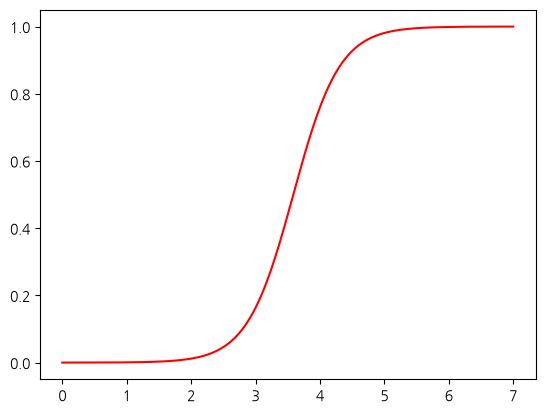

In [19]:
X_test = np.linspace(0,7,200)
y_prob = sigmoid(best_a * X_test + best_b)
plt.plot(X_test, y_prob, color = 'red')
plt.show()

2.787878787878788
-10.0
0.06763270092558238


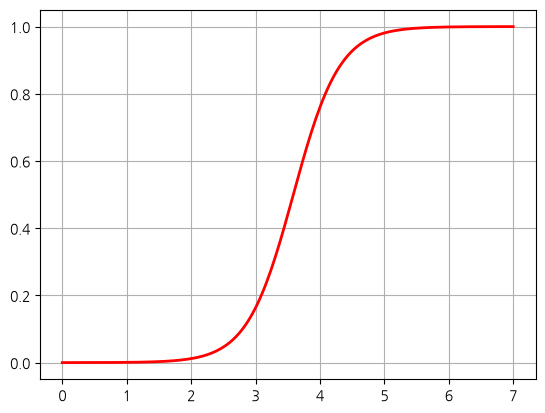

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def get_loss(y , y_hat):
  #return np.sum((y - y_hat)**2) # MSE는 주석처리

  #크로스 엔트로피
  eps = 1e-10
  return -np.mean(y*np.log(y_hat+eps) + (1-y)* np.log(1-y_hat+eps))

X = np.array([1,5,2,6,7,3,1,2,3,4]) # 공부시간
y = np.array([0,1,0,1,1,0,0,0,0,1]) # 합격여부( 0 - 불합격, 1 - 합격)

a_values = np.linspace(0,3,100)
b_values = np.linspace(-10,10,100)

best_a, best_b = None, None
min_loss = float("inf")

#Grid Search
for a in a_values:
  for b in b_values:
    y_hat = sigmoid(a * X + b) # X의 모든 데이터로 예측값들 y_hat 만듥;

    loss = get_loss(y , y_hat)

    if loss < min_loss:
      min_loss = loss
      best_a, best_b = a, b

print(best_a)
print(best_b)
print(min_loss)

# 최적 파라미터 곡선
X_test = np.linspace(0, 7, 200)
y_prob = sigmoid(best_a * X_test + best_b)

plt.plot(X_test, y_prob, color='red', linewidth= 2)
plt.grid(True)
plt.show()

Epoch 0, Loss=0.4927, a=0.4628, b=-0.1585
Epoch 500, Loss=0.1919, a=1.1326, b=-3.5483
Epoch 1000, Loss=0.1389, a=1.5473, b=-5.1052
Epoch 1500, Loss=0.1141, a=1.8402, b=-6.1758
Epoch 2000, Loss=0.0988, a=2.0728, b=-7.0162
Epoch 2500, Loss=0.0881, a=2.2689, b=-7.7197
Epoch 3000, Loss=0.0800, a=2.4402, b=-8.3314
Epoch 3500, Loss=0.0736, a=2.5933, b=-8.8763
Epoch 4000, Loss=0.0684, a=2.7323, b=-9.3702
Epoch 4500, Loss=0.0639, a=2.8602, b=-9.8235
2.9786155185218623
-10.242717697389347
0.060115360098514155



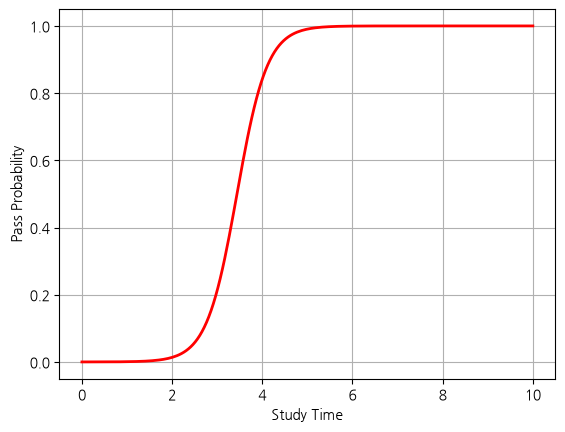

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 공부 시간 (X), 합격 여부 (y)
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10])
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 하이퍼 파라미터 초기화
lr = 0.1  # 학습률
epochs = 5000

np.random.seed(42)  # 재현성 고정
a = np.random.randn()  # 기울기
b = np.random.randn()  # 절편

# Gradient Descent
for epoch in range(epochs):

    y_hat = sigmoid(a * X + b)

    # Loss (Cross Entropy)
    eps = 1e-10
    loss = -np.mean(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))

    error = y_hat - y
    grad_a = np.mean(error * X)
    grad_b = np.mean(error)


    a -= lr * grad_a
    b -= lr * grad_b

    # Loss값 출력
    if epoch % 500 == 0:
      print(f"Epoch {epoch}, Loss={loss:.4f}, a={a:.4f}, b={b:.4f}")

# 학습 결과
print(a)
print(b)
print(loss)

# 시각화
X_test = np.linspace(0, 10, 200)
y_prob = sigmoid(a * X_test + b)

plt.plot(X_test, y_prob, color="red", linewidth=2)
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()


# Scikit - Learn
입력은 무조건 2차원 행렬로 변환해야함  
reshape(n, 1) -> 행렬을 nx1 차원으로 변경해줌  
reshape(-1, 1) -> 행의 갯수는 알아서 하라고 맡기는 것

In [22]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


X shape : (244, 1)


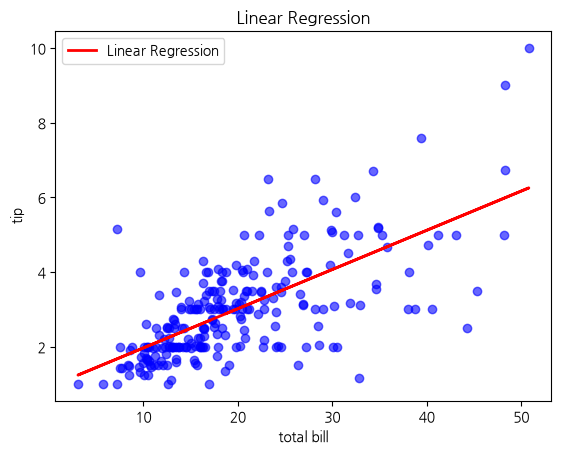

In [23]:
from sklearn.linear_model import LinearRegression
# tips['total_bill']는 그냥 (244,) 인 1차원 배열
X = tips['total_bill'].values.reshape(-1,1)
# X = tips[['total_bills']].values 으로 사용해도 됨

y = tips['tip'].values

lr = LinearRegression()
lr.fit(X, y)

y_hat = lr.predict(X)

print(f"X shape : {X.shape}")
plt.scatter(X, y, color = 'blue', alpha = 0.6)
plt.plot(X, y_hat, color = 'red', linewidth = 2, label = 'Linear Regression')
plt.xlabel("total bill")
plt.ylabel("tip")
plt.title('Linear Regression')
plt.legend()
plt.show()

(200, 2)


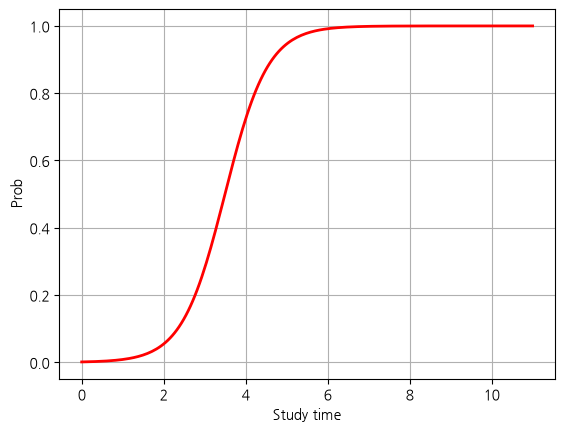

In [ ]:
from sklearn.linear_model import LogisticRegression

# 공부 시간 (X), 합격 여부 (y)
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

model = LogisticRegression()
model.fit(X, y)

X_new = np.linspace(0,11,200).reshape(-1,1)
# 모델로 예측한 확률 () : 2차원 배열
# 1번째 열은 클래스가 0일 확률 / 2번째 열은 클래스가 1일 확률
y_hat = model.predict_proba(X_new)
print(y_hat.shape)

plt.plot(X_new, y_hat[:,1], color = 'red', linewidth = 2)
plt.xlabel('Study time')
plt.ylabel('Prob')
plt.grid(True) 

# 데이터 전처리 (표준화)

Text(0, 0.5, 'Tip')

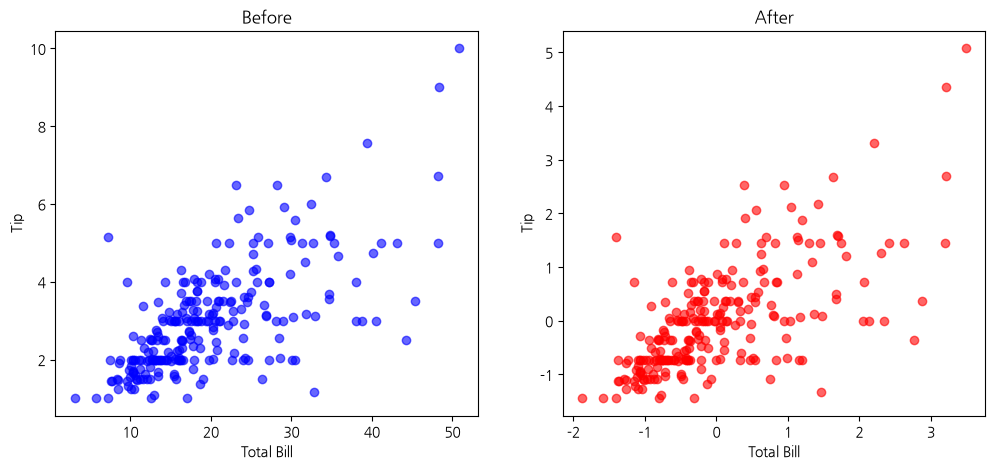

In [31]:
from sklearn.preprocessing import StandardScaler

X = tips[['total_bill']].values
y = tips[['tip']].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# scaler에 X와 y의 평균, 표준편차 계산
scaler_X.fit(X)
scaler_y.fit(y)

# 데이터 표준화
X_std = scaler_X.transform(X)
y_std = scaler_y.transform(y)

fig, axes = plt.subplots(1, 2, figsize = (12,5))

# 원본
axes[0].scatter(X, y, color = 'blue', alpha = 0.6)
axes[0].set_title('Before')
axes[0].set_xlabel('Total Bill')
axes[0].set_ylabel('Tip')

# 표준화
axes[1].scatter(X_std, y_std, color = 'red', alpha = 0.6)
axes[1].set_title('After')
axes[1].set_xlabel('Total Bill')
axes[1].set_ylabel('Tip')

In [33]:
from sklearn.model_selection import train_test_split

print(f"X 원본 개수 : {X.shape}, y 원본 개수 : {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(f"X Training Set: {X_train.shape}, y Training Set : {y_train.shape}")
print(f"X Test 개수 : {X_test.shape}, y Test set : {y_test.shape}")


X 원본 개수 : (244, 1), y 원본 개수 : (244, 1)
X Training Set: (195, 1), y Training Set : (195, 1)
X Test 개수 : (49, 1), y Test set : (49, 1)
